# Essentia EmoMusic — Valence Key Correction Benchmark

Evaluates the production Essentia pipeline with the key-mode valence correction
from `feat/valence_key_correction` applied on top of the raw model output.

**Correction formula:** `valence += α × (is_major − 0.5) × key_strength`  
where `α = 0.13` (calibrated on EmoMusic: mean valence major ≈ 5.8/9 vs minor ≈ 4.6/9)
and `key_strength` is the HPCP-based KeyExtractor confidence ∈ [0, 1].

> **Run this notebook in its own Colab runtime** — do not mix with `02_music2emo_benchmark.ipynb`.
> Essentia pins numpy ~1.x; the two environments are incompatible in the same kernel.

### Sections
0. Environment setup
1. Shared evaluation utilities
2. Essentia model files
3. Predictor (with key-mode valence correction)
4. Datasets
5. Evaluation
6. Qualitative spot-checks
7. Profiling
8. Summary


## 0. Environment Setup

In [1]:
!pip install essentia-tensorflow yt-dlp librosa matplotlib pandas scipy tqdm gdown -q
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.4 MB/s eta 0:00:00
Setup complete.


## 1. Shared Evaluation Utilities

In [ ]:
import os, sys
from pathlib import Path

REPO_BRANCH = "feat/mood-model-benchmark"
REPO_NAME   = "Soundtrack-Mood-Manager"

_cwd = Path.cwd()
if (_cwd / "eval_datasets.py").exists():
    _eval_dir = _cwd
else:
    _repo_root = _cwd / REPO_NAME
    if not (_repo_root / "evaluation").exists():
        !git clone --depth 1 --branch {REPO_BRANCH} \
            https://github.com/francescovidaich964/{REPO_NAME}.git
    _eval_dir = _repo_root / "evaluation"

_eval_dir = _eval_dir.resolve()
if str(_eval_dir) not in sys.path:
    sys.path.insert(0, str(_eval_dir))

from eval_datasets import (setup_deam, setup_emomusic, setup_pmemo, setup_merge,
                            detect_audio_paths, download_model_files)
from metrics import compute_metrics, print_metrics, print_summary
from visualization import plot_scatter, cross_dataset_comparison, plot_spot_checks
from spot_checks import (SPOT_CHECKS, download_spot_checks, run_evaluation,
                         profile_predictor, run_spot_checks, save_results)

import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR      = Path("data")
MODELS_DIR    = Path("models")
SPOTCHECK_DIR = Path("spotchecks")
for d in [DATA_DIR, MODELS_DIR, SPOTCHECK_DIR]:
    d.mkdir(exist_ok=True)

MODEL_TAG = "essentia-valence-corrected"
print(f"Imports complete. (eval_dir={_eval_dir})")

## 2. Download Essentia Model Files

Same `.pb` files used by the production sync pipeline.

In [ ]:
MODEL_URLS = {
    "msd-musicnn-1.pb":
        "https://essentia.upf.edu/models/feature-extractors/musicnn/msd-musicnn-1.pb",
    "emomusic-msd-musicnn-2.pb":
        "https://essentia.upf.edu/models/classification-heads/emomusic/emomusic-msd-musicnn-2.pb",
}

download_model_files(MODEL_URLS, MODELS_DIR)

## 3. Predictor

In [4]:
# Valence correction alpha: calibrated on EmoMusic (major vs minor gap ≈ 0.13)
_ALPHA = 0.13


class EssentiaPredictor:
    """Production pipeline with key-mode valence correction.

    Mirrors src/feature_extractor.py on feat/valence_key_correction; inlined
    here so the notebook is self-contained.

    The KeyExtractor runs on the same 16 kHz mono audio and returns the
    detected key, scale (major/minor), and a confidence score (key_strength).
    The correction shifts valence toward the major/minor mean observed in
    EmoMusic, weighted by confidence so ambiguous/atonal tracks get ≈ zero
    correction. Full-confidence major: +0.065 | full-confidence minor: −0.065.

    NOTE ON GPU: essentia-tensorflow is compiled CPU-only (no GPU wheels on PyPI).
    Selecting a GPU runtime in Colab does not accelerate this notebook.
    """

    def __init__(self, models_dir: Path, batch_size: int = 256):
        import essentia
        essentia.log.warningActive = False
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from essentia.standard import (
                MonoLoader, TensorflowPredictMusiCNN, TensorflowPredict2D, KeyExtractor,
            )
        self._MonoLoader = MonoLoader
        self._musicnn = TensorflowPredictMusiCNN(
            graphFilename=str(models_dir / "msd-musicnn-1.pb"),
            output="model/dense/BiasAdd",
            batchSize=batch_size,
        )
        self._emomusic = TensorflowPredict2D(
            graphFilename=str(models_dir / "emomusic-msd-musicnn-2.pb"),
            output="model/Identity",
            batchSize=batch_size,
        )
        self._key_extractor = KeyExtractor(sampleRate=16000)
        print(f"EssentiaPredictor (valence-corrected) ready (CPU, batchSize={batch_size}).")

    def predict(self, audio_path) -> dict | None:
        """Returns {'valence': float, 'arousal': float} in [0, 1], or None on failure."""
        try:
            audio = self._MonoLoader(filename=str(audio_path), sampleRate=16000)()

            # Key detection for valence correction.
            try:
                _key, scale, key_strength = self._key_extractor(audio)
                is_major = 1.0 if scale == "major" else 0.0
            except Exception:
                is_major, key_strength = 0.5, 0.0  # neutral: no correction

            embeddings = self._musicnn(audio)
            if embeddings.shape[0] == 0:
                return None
            preds = self._emomusic(embeddings)
            if preds.shape[0] == 0:
                return None
            mean = preds.mean(axis=0)
            valence = float(np.clip((mean[0] - 1.0) / 8.0, 0.0, 1.0))
            arousal = float(np.clip((mean[1] - 1.0) / 8.0, 0.0, 1.0))

            # Apply key-mode valence correction weighted by detection confidence.
            valence = float(np.clip(valence + _ALPHA * (is_major - 0.5) * key_strength, 0.0, 1.0))

            if not (math.isfinite(valence) and math.isfinite(arousal)):
                return None
            return {"valence": valence, "arousal": arousal}
        except Exception:
            return None


predictor = EssentiaPredictor(MODELS_DIR)


[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


EssentiaPredictor (valence-corrected) ready (CPU, batchSize=256).


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/emomusic-msd-musicnn-2.pb`


## 4. Datasets

Annotations are downloaded automatically where possible.
See the printed instructions for datasets that require manual setup.

In [5]:
df_deam,     deam_id, deam_val, deam_aro = setup_deam(DATA_DIR,  download_audio=True)
df_emomusic, em_id,   em_val,   em_aro   = setup_emomusic(DATA_DIR)
df_pmemo,    pm_id,   pm_val,   pm_aro   = setup_pmemo(DATA_DIR)
df_merge,    mg_id,   mg_val,   mg_aro   = setup_merge(DATA_DIR, download_audio=True)

Extracting DEAM_Annotations.zip...
Extracting DEAM_audio.zip...
DEAM: 1802 songs  id='song_id'  valence='valence_mean'  arousal='arousal_mean'
⚠  EmoMusic unavailable — official download links return 404 (as of 2025-06).
   If you have a local copy, place annotations.csv in data/emomusic/
   and audio .mp3 files in data/emomusic/clips/


Retrieving folder contents


Processing file 1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ PMEmo2019.zip
Processing file 1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq README.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ
From (redirected): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ&confirm=t&uuid=7e3fd089-9728-44f3-b666-f52141a09cc1
To: /kaggle/working/data/pmemo/PMEmo2019.zip
100%|██████████| 680M/680M [00:05<00:00, 119MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq
To: /kaggle/working/data/pmemo/README.txt
100%|██████████| 1.52k/1.52k [00:00<00:00, 2.15MB/s]
Download completed


Extracting PMEmo2019.zip...
PMEmo: 767 rows  id='musicId'  valence='Valence(mean)'  arousal='Arousal(mean)'
Extracting MERGE_Audio_Balanced.zip...
MERGE: 3232 rows  id='Song'  valence='Valence'  arousal='Arousal'


## 5. Evaluation

Set the audio directory paths below, then run the evaluation loop.
Datasets without audio are skipped automatically.

In [ ]:
audio_paths = detect_audio_paths(DATA_DIR)

# ── Speed note ────────────────────────────────────────────────────────────────
# essentia-tensorflow is CPU-only regardless of runtime type.
# Selecting a T4 GPU in Colab does NOT help here.
# Speed is controlled by batchSize in EssentiaPredictor (set above to 256).
# At ~4 s/track on CPU: DEAM ~2 h, PMEmo ~50 min, MERGE ~3.5 h.
MAX_TRACKS = None  # set to e.g. 200 for a quick sanity check

DATASETS = [
    ("DEAM",     df_deam,     audio_paths["DEAM"],     deam_id, deam_val, deam_aro),
    ("EmoMusic", df_emomusic, audio_paths["EmoMusic"], em_id,   em_val,   em_aro),
    ("PMEmo",    df_pmemo,    audio_paths["PMEmo"],    pm_id,   pm_val,   pm_aro),
    ("MERGE",    df_merge,    audio_paths["MERGE"],    mg_id,   mg_val,   mg_aro),
]

all_results = {}
for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
    if df_a is None or not audio_dir.exists():
        print(f"Skipping {ds_name} — audio not found at {audio_dir}")
        continue
    all_results[ds_name] = run_evaluation(
        ds_name, MODEL_TAG, predictor.predict,
        audio_dir, df_a, id_col, val_col, aro_col, MAX_TRACKS,
    )


── DEAM ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.1006 0.2555    0.5381    0.3812
    arousal 1802 0.0906 0.4726    0.6965    0.5303


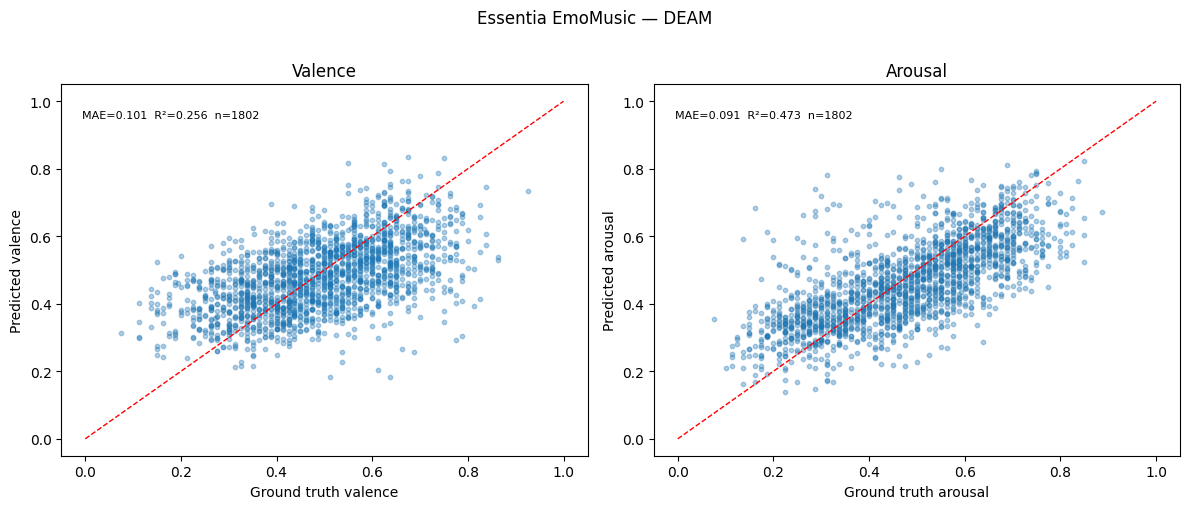

Saved: essentia_emomusic_—_deam.png

── PMEmo ──
  PMEmo:
        Dim   n    MAE     R² Pearson r Kendall τ
    valence 767 0.1111 0.2818    0.6258    0.4481
    arousal 767 0.1076 0.4897    0.7455    0.5435


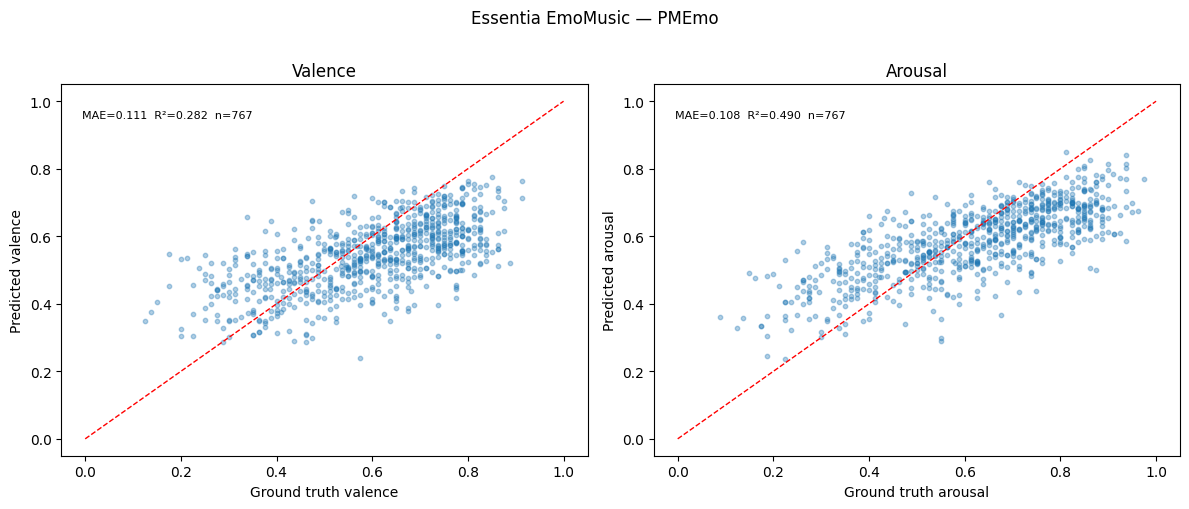

Saved: essentia_emomusic_—_pmemo.png

── MERGE ──
  MERGE:
        Dim    n    MAE      R² Pearson r Kendall τ
    valence 3232 0.1783  0.1487    0.4218    0.2783
    arousal 3232 0.1108 -0.0127    0.6246    0.4399


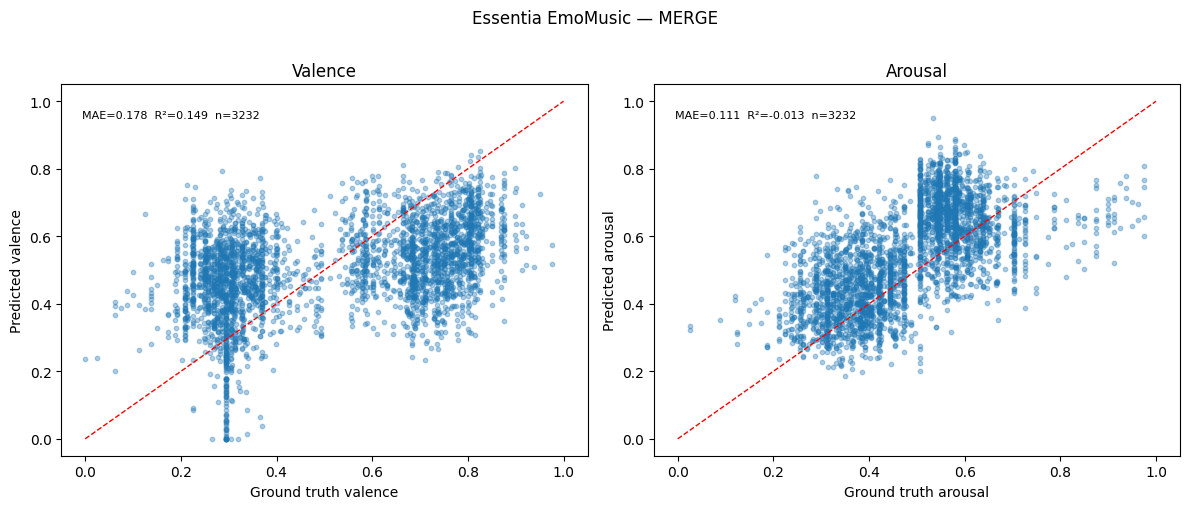

Saved: essentia_emomusic_—_merge.png


In [7]:
# Metrics and scatter plots per dataset
for ds_name, df in all_results.items():
    print_metrics(df, ds_name)
    plot_scatter(df, f"Essentia EmoMusic — {ds_name}")

In [ ]:
save_results(all_results, MODEL_TAG)

## 6. Qualitative Spot-checks

Five well-known tracks spanning all four mood quadrants, downloaded via `yt-dlp`.

In [9]:
download_spot_checks(SPOTCHECK_DIR)

In [ ]:
spot_df = run_spot_checks(predictor.predict, SPOTCHECK_DIR)

In [ ]:
plot_spot_checks(spot_df, MODEL_TAG)

## 7. Runtime & Memory Profiling

`tracemalloc` measures Python heap allocations only.

In [12]:
test_audio = next(
    (SPOTCHECK_DIR / f"{t['title']}.mp3" for t in SPOT_CHECKS
     if (SPOTCHECK_DIR / f"{t['title']}.mp3").exists()),
    None,
)

if test_audio is None:
    print("No audio for profiling — run Section 6 first.")
else:
    prof = profile_predictor(predictor.predict, test_audio, n=5)
    print(f"Essentia EmoMusic — profiling on {test_audio.name}:")
    print(f"  Mean: {prof['mean_s']:.2f} s/track")
    print(f"  Std:  {prof['std_s']:.3f} s")
    print(f"  Peak RAM: {prof['peak_mb']:.1f} MB")

Essentia EmoMusic — profiling on dont_stop_me_now.mp3:
  Mean: 13.43 s/track
  Std:  0.083 s
  Peak RAM: 0.1 MB


## 8. Summary

In [ ]:
prof_or_none = prof if "prof" in dir() else None
print_summary(all_results, spot_df, prof_or_none, MODEL_TAG)